<!-- reader-content -->

# Pulses, leakage, and readout

How does pulse duration affect leakage, and how does the qubit state appear in
resonator readout? Use one coupled model for both experiments. Frequencies are
in GHz and times in ns.

## Declare the chip

The transmon couples to a 6.8 GHz resonator with a 1 MHz linewidth. Separate
charge lines address the qubit and the readout.

In [1]:
import numpy as np
from scipy import integrate
from quchip import (
    RWA, Capacitive, ChargeDrive, Chip, DuffingTransmon,
    Gaussian, GaussianEdge, QuantumSequence, Resonator,
)

qubit = DuffingTransmon(freq=5.0, anharmonicity=-0.30, levels=6, label="q")
readout = Resonator(freq=6.8, levels=10, internal_quality_factor=6800, label="r")
chip = Chip(
    [qubit, readout], [Capacitive(qubit, readout, g=0.060, label="qr")],
    frame="rotating", approximation=RWA(),
)

qubit_line = ChargeDrive(qubit, label="qubit-charge")
readout_line = ChargeDrive(readout, label="readout-charge")
_ = chip.wire(qubit_line, readout_line)

## Compare a short and a long qubit pulse

Both Gaussians have the same nominal π area. The short pulse's spectral width
is comparable to the separation between the dressed 0→1 and 1→2 transitions;
the four-times-longer pulse is more selective.

In [2]:
f01 = float(chip.freq(qubit))
f12 = float(chip.transition_frequency(qubit, 1, 2))
drive_durations = 3 / (np.pi * abs(f12 - f01)) * np.array([1.0, 4.0])


def pi_gaussian(duration):
    unit_pulse = Gaussian(duration=duration, sigmas=3.0, amplitude=1.0)
    grid = np.linspace(0, duration, 20001)
    area = integrate.trapezoid(np.asarray(unit_pulse.value(grid)).real, grid)
    return Gaussian(duration=duration, sigmas=3.0, amplitude=0.5 / area)


drive_pulses = [pi_gaussian(duration) for duration in drive_durations]

Schedule the short pulse, then vary its duration and amplitude together.
Each batch member starts in dressed |0,0⟩ and uses the same time grid.

In [3]:
drive_sequence = QuantumSequence(chip)
drive = drive_sequence.schedule(qubit_line, envelope=drive_pulses[0], freq=f01)
drive_times = np.linspace(0, drive_durations[-1], 601)

drive_batch = drive_sequence.simulate_batch(
    drive_sequence.zip(
        drive.vary("duration", drive_durations),
        drive.vary("amplitude", [pulse.amplitude for pulse in drive_pulses]),
    ),
    tlist=drive_times,
    initial_state=chip.state({qubit: 0, readout: 0}),
    progress=False,
)

Read the populations of |0⟩, |1⟩, and |2⟩. The arrays are indexed by
`(level, pulse, time)`.

In [4]:
drive_populations = np.asarray([
    drive_batch.population(qubit, level) for level in range(3)
]).real

<details>
<summary>Plot the envelopes and populations</summary>

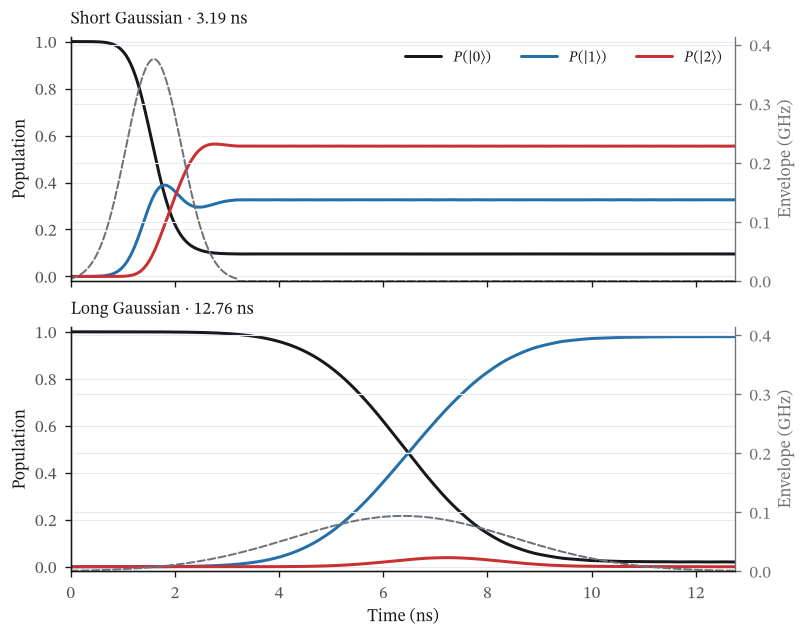

In [5]:
import shutil
import matplotlib.pyplot as plt

plt.style.use("../docs/_static/quchip.mplstyle")
plt.rcParams["text.usetex"] = bool(shutil.which("latex"))

colors = ("#16181C", "#246FA8", "#C92F33")

figure, axes = plt.subplots(2, 1, figsize=(6.6, 5.2), sharex=True, layout="constrained")
for index, (axis, name, envelope) in enumerate(zip(axes, ("Short", "Long"), drive_pulses)):
    for level, color in enumerate(colors):
        axis.plot(drive_times, drive_populations[level, index], color=color,
                  lw=1.8, label=fr"$P(|{level}\rangle)$")
    pulse_axis = axis.twinx()
    pulse_axis.plot(drive_times, np.where(drive_times <= envelope.duration,
                    envelope.sample(drive_times, real=True), 0.0),
                    color="#6D7277", ls="--", lw=1.2)
    pulse_axis.set(ylabel="Envelope (GHz)", ylim=(0, 1.1 * drive_pulses[0].amplitude))
    pulse_axis.spines["right"].set_visible(True)
    pulse_axis.spines["right"].set_color("#6D7277")
    pulse_axis.yaxis.label.set_color("#6D7277")
    pulse_axis.tick_params(axis="y", colors="#6D7277")
    axis.set(ylabel="Population", ylim=(-0.02, 1.02), xlim=(0, drive_times[-1]))
    axis.set_title(fr"{name} Gaussian $\cdot$ {envelope.duration:.2f} ns")

axes[0].legend(ncol=3, loc="upper right", fontsize=9)
axes[1].set_xlabel("Time (ns)")

figure.savefig("../docs/images/hello_qubit_drive_leakage.svg")

figure.savefig("../docs/images/hello_qubit_drive_leakage.png")
plt.show()

</details>

```{figure} ../images/hello_qubit_drive_leakage.svg
:alt: Short and long Gaussian envelopes with ground, excited, and leakage populations over time.

Dashed grey curves show the drive envelopes. The short pulse populates |2⟩;
the longer pulse leaves most population in |1⟩. [PDF](../images/hello_qubit_drive_leakage.pdf)
```

In [6]:
for index, name in enumerate(("Short", "Long")):
    print(
        f"{name}: final P1 = {drive_populations[1, index, -1]:.1%}; "
        f"peak P2 = {drive_populations[2, index].max():.1%}"
    )

Short: final P1 = 32.6%; peak P2 = 56.4%
Long: final P1 = 98.0%; peak P2 = 3.9%


Equal pulse area does not guarantee equal inversion in a multilevel system.
The smaller peak P2 explains why the longer pulse comes closer to the target.

## Read out the prepared qubit state

Now drive the resonator. Its frequency depends on the qubit state; use a tone
halfway between the dressed resonances for qubit states |0⟩ and |1⟩.
Use the same RWA Hamiltonian as the simulation, and set `reference_freq`
to the carrier to view the IQ response in the drive frame.

In [7]:
readout_dressed = chip.resolve(frame="lab").dress()
readout_energies = readout_dressed.dressed_eigenvalues
readout_frequencies = [
    float(readout_energies[(level, 1)] - readout_energies[(level, 0)])
    for level in (0, 1)
]
readout_carrier = np.mean(readout_frequencies)
readout.reference_freq = readout_carrier

readout_pulse = GaussianEdge(duration=900.0, edge_duration=40.0, sigmas=3, amplitude=0.0012)
readout_sequence = QuantumSequence(chip)
_ = readout_sequence.schedule(readout_line, envelope=readout_pulse, freq=readout_carrier)

Apply the same pulse to separately prepared dressed |0,0⟩ and |1,0⟩ states.
These are fresh preparations, so the readout comparison does not inherit the
leakage from the previous experiment. Follow the two IQ pointers during
the 900 ns readout pulse.

In [8]:
readout_times = np.linspace(0, 900, 181)

readout_batch = readout_sequence.simulate_batch(
    readout_sequence.vary(
        "initial_state",
        [readout_dressed.eigenstates[readout_dressed.state_map[(level, 0)]]
         for level in (0, 1)],
        name="prepared_qubit",
    ),
    tlist=readout_times,
    e_ops=chip.e_ops(r="a"),
    progress=False,
)

`expect("r")` returns the requested α(t) = ⟨a⟩. Compare the two complex
responses and their separation over time.

In [9]:
alpha = np.asarray(readout_batch.expect("r"), dtype=complex)
iq_separation = np.abs(alpha[0] - alpha[1])

<details>
<summary>Plot the readout pulse and IQ response</summary>

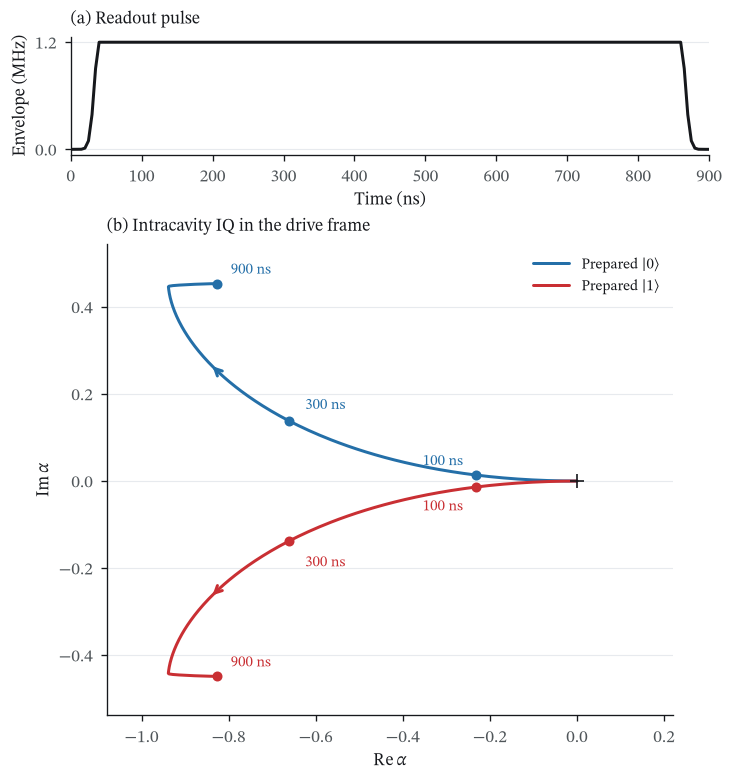

In [10]:
figure, (time_axis, iq_axis) = plt.subplots(2, 1, figsize=(6.0, 6.4),
                                         height_ratios=(0.55, 2.2), layout="constrained")

time_axis.plot(readout_times, 1000 * readout_pulse.sample(readout_times, real=True),
               color="#16181C", lw=1.8)
time_axis.set(xlabel="Time (ns)", ylabel="Envelope (MHz)", xlim=(0, 900), yticks=[0, 1.2])
time_axis.set_title("(a) Readout pulse")

for level, color in enumerate(("#246FA8", "#C92F33")):
    path = alpha[level]
    iq_axis.plot(path.real, path.imag, color=color, lw=1.8,
                 label=fr"Prepared $|{level}\rangle$")
    for time in (100, 300, 900):
        point = path[np.searchsorted(readout_times, time)]
        iq_axis.plot(point.real, point.imag, "o", color=color, ms=5)
        offset = {100: (-8, 6 if level == 0 else -14), 300: (10, 7 if level == 0 else -15), 900: (8, 6)}
        iq_axis.annotate(f"{time} ns", (point.real, point.imag), xytext=offset[time],
                         textcoords="offset points", ha="right" if time == 100 else "left",
                         color=color, fontsize=9)
    start, end = path[90], path[96]
    iq_axis.annotate("", (end.real, end.imag), (start.real, start.imag),
                     arrowprops={"arrowstyle": "->", "color": color, "lw": 1.8})

iq_axis.plot(0, 0, "+", color="#16181C", ms=8)
iq_axis.set(xlabel=r"$\mathrm{Re}\,\alpha$", ylabel=r"$\mathrm{Im}\,\alpha$",
            xlim=(1.15 * alpha.real.min(), 0.22), ylim=(1.2 * alpha.imag.min(), 1.2 * alpha.imag.max()))
iq_axis.set_title("(b) Intracavity IQ in the drive frame")
iq_axis.set_aspect("equal", adjustable="box")
iq_axis.legend(fontsize=9, loc="upper right")

figure.savefig("../docs/images/hello_dispersive_readout_iq.svg")

figure.savefig("../docs/images/hello_dispersive_readout_iq.png")
plt.show()

</details>

```{figure} ../images/hello_dispersive_readout_iq.svg
:alt: Readout pulse with two drive-frame IQ trajectories marked at 100, 300, and 900 ns.
:class: wide-figure

Above: the readout pulse envelope. Below: the
IQ pointers traced during readout, with time markers and arrows showing
the direction of motion. The cross marks zero field.
[PDF](../images/hello_dispersive_readout_iq.pdf)
```

The same drive produces distinguishable mean fields for the two qubit states.
These are intracavity responses, not a single-shot fidelity estimate.

<details>
<summary>Numerical checks and record</summary>

In [11]:
import json

for result in (*drive_batch, *readout_batch):
    top_levels = result.check_truncation(threshold=1.0)
    assert max(top_levels.values()) < 1e-3

drive_receipt = {
    "final_p1": dict(zip(("short", "long"), drive_populations[1, :, -1])),
    "peak_p2": dict(zip(("short", "long"), drive_populations[2].max(axis=-1))),
}
readout_receipt = {
    "conditional_resonator_frequencies_ghz": readout_frequencies,
    "final_iq_separation": float(iq_separation[-1]),
    "solver": readout_batch[0].solver,
}
print(f"RESULT drive={json.dumps(drive_receipt, sort_keys=True)}")
print(f"RESULT readout={json.dumps(readout_receipt, sort_keys=True)}")

RESULT drive={"final_p1": {"long": 0.9798521681976914, "short": 0.32629522511065323}, "peak_p2": {"long": 0.03870269369477974, "short": 0.5637970570726827}}
RESULT readout={"conditional_resonator_frequencies_ghz": [6.801997782702374, 6.801428548310606], "final_iq_separation": 0.9021197297304233, "solver": "mesolve"}


</details>

## Empty the resonator after readout

Turning off a readout pulse leaves photons to decay. A
[CLEAR pulse](https://arxiv.org/abs/1503.01456) adds loading and depletion
segments to bring the coherent field up and back down faster.

Use the filtered circuit from the [T1 guide](slh-networks.md): a 5 GHz
transmon, a 7 GHz readout resonator, and a 7.02 GHz Purcell filter. The line
couples to the filter. Both pulses use the same 7.004945 GHz carrier: a
weak-drive estimate of the conditional response midpoint including the
lossy filter. Use that carrier as the IQ reference too.

In [12]:
from quchip import Capacitive, Chip, DuffingTransmon, PortNetwork, QuantumSequence, Resonator, RWA, Square

clear_carrier = 7.004945346
clear_q = DuffingTransmon(freq=5.0, anharmonicity=-0.2, levels=3, T1=60_000, label="q")
clear_r = Resonator(freq=7.0, levels=4, internal_quality_factor=200_000, label="r")
clear_f = Resonator(freq=7.02, levels=2, internal_quality_factor=100_000, label="f")
clear_r.reference_freq = clear_carrier

clear_network = PortNetwork(label="feedline")
filter_rate = 2 * np.pi * 0.230
chip_port = clear_network.expose("feedline", at=clear_network.port("feed", target=clear_f, rate=filter_rate))

clear_chip = Chip(
    [clear_q, clear_r, clear_f],
    [Capacitive(clear_q, clear_r, g=0.105, label="qr"),
     Capacitive(clear_r, clear_f, g=0.007696696, label="rf")],
    port_network=clear_network, frame=clear_carrier, approximation=RWA(),
)

Both pulses start at 100 ns and use the same carrier and hold amplitude
(in √photons/ns).
The square pulse stops at 900 ns. CLEAR uses two loading segments, a hold,
then two depletion segments ending at 1300 ns. A negative amplitude is a π
phase reversal. These five coefficients are a weak-drive starting design
for this circuit; changing the circuit or carrier requires retuning them.

In [13]:
hold_amplitude = 0.008
segment_amplitudes = np.array([2.318735, 0.378724, 1.0, -1.318735, 0.621276])
segment_edges = np.array([100, 300, 500, 900, 1100, 1300])

square_sequence = QuantumSequence(clear_chip)
_ = square_sequence.schedule(chip_port.input, envelope=Square(duration=800, amplitude=hold_amplitude),
                             freq=clear_carrier, start_time=100)

clear_sequence = QuantumSequence(clear_chip)
for start, duration, scale in zip(segment_edges[:-1], np.diff(segment_edges), segment_amplitudes):
    _ = clear_sequence.schedule(
        chip_port.input, envelope=Square(duration=duration, amplitude=hold_amplitude * abs(scale)),
        phase=np.pi if scale < 0 else 0, freq=clear_carrier, start_time=start,
    )

Prepare dressed |0,0,0⟩ and |1,0,0⟩ states of the resolved RWA model and
run each pulse on both preparations. Record occupations and the readout field
αᵣ = ⟨aᵣ⟩. The explicit time grid resolves the fast qubit–resonator exchange.
The `matrix_form` solver option requires [QuTiP 5.3+](https://qutip.readthedocs.io/en/qutip-5.3.x/apidoc/solver.html).

In [14]:
clear_times = np.linspace(0, 1900, 9501)
clear_dressed = clear_chip.resolve().dress(overlap_threshold=0.0)
clear_preparations = [clear_dressed.eigenstates[clear_dressed.state_map[(level, 0, 0)]] for level in (0, 1)]

clear_batches = {}
for name, pulse_sequence in [("Square", square_sequence), ("CLEAR", clear_sequence)]:
    clear_batches[name] = pulse_sequence.simulate_batch(
        pulse_sequence.vary("initial_state", clear_preparations), tlist=clear_times,
        e_ops=clear_chip.e_ops(q="n", r=["n", "a"], f="n"),
        states="none", progress=False,
        options={"method": "vern9", "matrix_form": True, "rtol": 1e-7, "atol": 1e-10},
    )

clear_occupations = {name: np.stack([batch.expect("q"), batch.expect("r", index=0), batch.expect("f")]).real
                     for name, batch in clear_batches.items()}
clear_iq = {name: np.asarray(batch.expect("r", index=1)) for name, batch in clear_batches.items()}

<details>
<summary>Plot pulse shapes and mode occupations</summary>

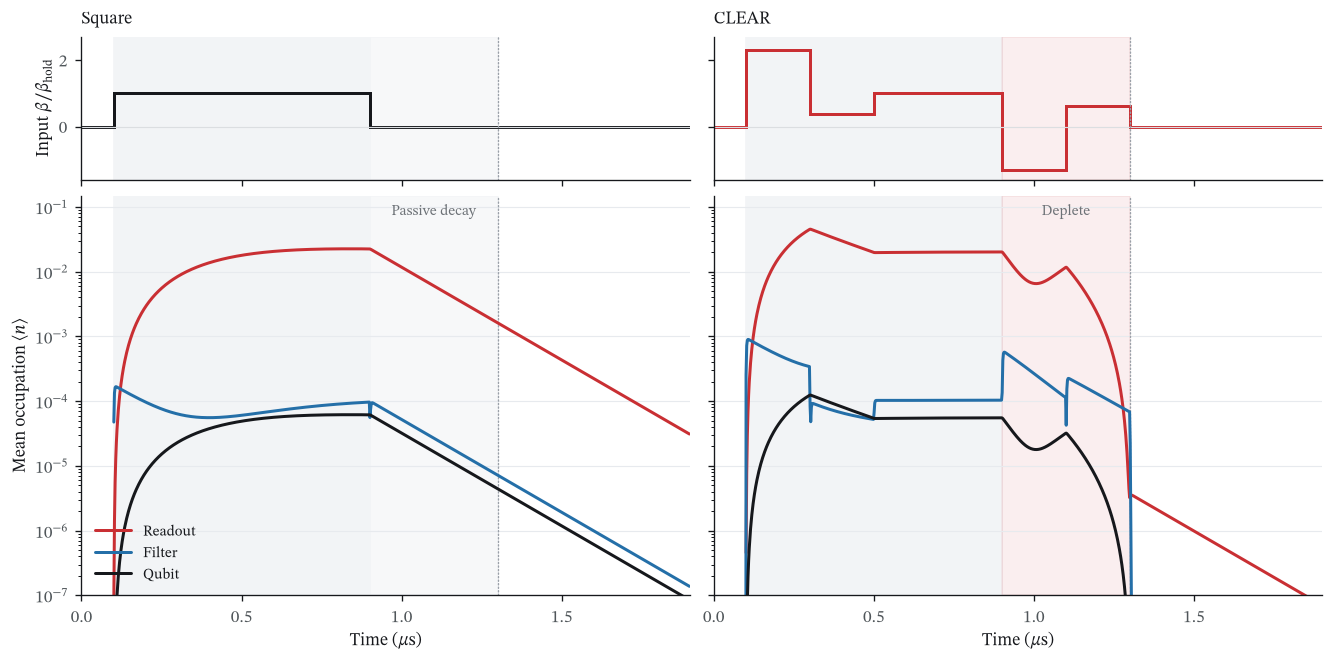

In [15]:
figure, axes = plt.subplots(2, 2, figsize=(11, 5.4), sharex=True, sharey='row',
                            height_ratios=(1, 2.8), layout='constrained')
plot_times = (clear_times[:-1:10] + clear_times[10::10]) / 2000
for column, name in enumerate(('Square', 'CLEAR')):
    pulse_axis, population_axis = axes[:, column]
    scales = np.array([1.0]) if name == 'Square' else segment_amplitudes
    edges = np.array([100, 900]) if name == 'Square' else segment_edges
    pulse_axis.stairs(np.r_[0, scales, 0], np.r_[0, edges, 1900] / 1000,
                       color='#16181C' if name == 'Square' else '#C92F33', lw=1.8)
    pulse_axis.set_title(name)
    pulse_axis.axhline(0, color="#DBDEE1", lw=.7)
    pulse_axis.set_ylim(-1.6, 2.7)
    pulse_axis.grid(False)
    for axis in (pulse_axis, population_axis):
        axis.axvspan(.1, .9, color='#F2F4F6', zorder=0)
        if name == 'CLEAR':
            axis.axvspan(.9, 1.3, color='#C92F33', alpha=0.08, zorder=0)
        else:
            axis.axvspan(.9, 1.3, color='#F2F4F6', alpha=0.6, zorder=0)
        axis.axvline(1.3, color='#9AA0A8', ls=':', lw=.8)
    # Trapezoidal means over 2 ns bins; state 0 is the ground preparation.
    values = clear_occupations[name][:, 0]
    averaged = (values[:, :-1].reshape(3, -1, 10).sum(axis=-1)
                - .5 * values[:, :-1:10] + .5 * values[:, 10::10]) / 10
    for index, label, color in ((1, 'Readout', '#C92F33'), (2, 'Filter', '#246FA8'), (0, 'Qubit', '#16181C')):
        population_axis.semilogy(plot_times, np.where(averaged[index] > 0, averaged[index], np.nan),
                                 color=color, lw=1.8, label=label)
    population_axis.text(1.1, .075, 'Deplete' if name == 'CLEAR' else 'Passive decay',
                         ha='center', color='#6D7277', fontsize=9)
    population_axis.set(xlabel=r'Time ($\mu$s)', xlim=(0, 1.9), ylim=(1e-7, .15), xticks=[0, .5, 1, 1.5])

axes[0, 0].set_ylabel(r'Input $\beta/\beta_{\mathrm{hold}}$')
axes[1, 0].set_ylabel(r'Mean occupation $\langle n\rangle$')
axes[1, 0].legend(fontsize=9, loc='lower left')

figure.savefig("../docs/images/clear_populations.svg")
plt.show()

</details>

```{figure} ../images/clear_populations.svg
:class: wide-figure
:alt: Square and CLEAR input pulses above the readout, filter, and qubit occupations, showing passive decay versus active depletion.

Ground-state preparation; occupations are averaged over 2 ns bins. CLEAR
uses extra drive during loading and depletion. Its final segments remove
readout photons much faster than waiting over the same 900–1300 ns interval.
The small qubit occupation includes hybridization with the resonator.
[PDF](../images/clear_populations.pdf)
```

The IQ paths show how the depletion segments steer the coherent readout field
back toward zero for both qubit preparations.

<details>
<summary>Plot the readout IQ trajectories</summary>

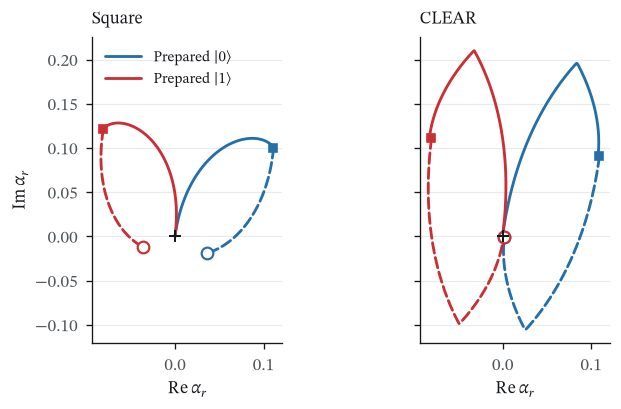

In [16]:
figure, axes = plt.subplots(1, 2, figsize=(5.6, 3.3), sharex=True, sharey=True, layout='constrained')
readout_end = np.searchsorted(clear_times, 900)
reset_end = np.searchsorted(clear_times, 1300)
for axis, name in zip(axes, ('Square', 'CLEAR')):
    for level, color in ((0, '#246FA8'), (1, '#C92F33')):
        iq = clear_iq[name][level]
        axis.plot(iq[:readout_end+1].real, iq[:readout_end+1].imag, color=color, lw=1.7,
                  label=fr'Prepared $|{level}\rangle$')
        axis.plot(iq[readout_end:reset_end+1].real, iq[readout_end:reset_end+1].imag,
                  color=color, ls='--', lw=1.7)
        axis.plot(iq[readout_end].real, iq[readout_end].imag, 's', color=color, ms=5)
        axis.plot(iq[reset_end].real, iq[reset_end].imag, 'o', mec=color, mfc='white', mew=1.3, ms=7)
    axis.plot(0, 0, '+', color='#16181C', ms=7, mew=1.2)
    axis.set_title(name)
    axis.set_xlabel(r'$\mathrm{Re}\,\alpha_r$')
    axis.set_aspect('equal', adjustable='box')

axes[0].set_ylabel(r'$\mathrm{Im}\,\alpha_r$')

axes[0].legend(fontsize=9, loc='upper left')

figure.savefig("../docs/images/clear_iq.svg")
plt.show()

</details>

```{figure} ../images/clear_iq.svg
:class: wide-figure
:alt: Readout IQ paths for both qubit preparations under square and CLEAR pulses, with the end of readout and end of depletion marked.

Squares mark 900 ns; open circles mark 1300 ns. Dashed paths cover that
interval. CLEAR brings both mean fields close to the origin. These paths
show coherent-field cancellation; |⟨aᵣ⟩|² is not the total photon occupation.
[PDF](../images/clear_iq.pdf)
```

<details>
<summary>Check depletion at the same elapsed time</summary>

In [17]:
reset_index = np.searchsorted(clear_times, 1300)
for values in clear_occupations.values():
    assert np.all(np.isfinite(values))
assert clear_occupations["CLEAR"][1, 0, reset_index] < clear_occupations["Square"][1, 0, reset_index] / 100
for level in (0, 1):
    assert clear_dressed.assignment_overlaps[(level, 0, 0)] > 0.99
    assert abs(clear_iq["CLEAR"][level, reset_index])**2 < abs(clear_iq["Square"][level, reset_index])**2 / 100

</details>

The excited preparation also carries its dressed qubit excitation, so zero
mean field does not imply a vacuum state. For the signal at the instrument
ports, continue with [readout and fridge wiring](steady-state-and-vna.md).